# 1. Import Project Dependencies

In [17]:
# import dependencies
import os
import sys
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# 2. Read dataset and observe the data structures

In [29]:
# read UCI_Credit_Card dataset
data = pd.read_csv('UCI_Credit_Card.csv')

# Print the first 5 rows of the dataset
print(data.head())

# Print the data types of each column
print(data.dtypes)

   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1    20000.0    2          2         1   24      2      2     -1     -1   
1   2   120000.0    2          2         2   26     -1      2      0      0   
2   3    90000.0    2          2         2   34      0      0      0      0   
3   4    50000.0    2          2         1   37      0      0      0      0   
4   5    50000.0    1          2         1   57     -1      0     -1      0   

   ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0  ...        0.0        0.0        0.0       0.0     689.0       0.0   
1  ...     3272.0     3455.0     3261.0       0.0    1000.0    1000.0   
2  ...    14331.0    14948.0    15549.0    1518.0    1500.0    1000.0   
3  ...    28314.0    28959.0    29547.0    2000.0    2019.0    1200.0   
4  ...    20940.0    19146.0    19131.0    2000.0   36681.0   10000.0   

   PAY_AMT4  PAY_AMT5  PAY_AMT6  default.payment.next.month  
0       0.0       0.0   

# 3. Check data quality, clean up if necessary

1. Missing values total for all columns:  0
2. ID column is unique for each client.
3. SEX column values are valid.
4. EDUCATION column values are valid.


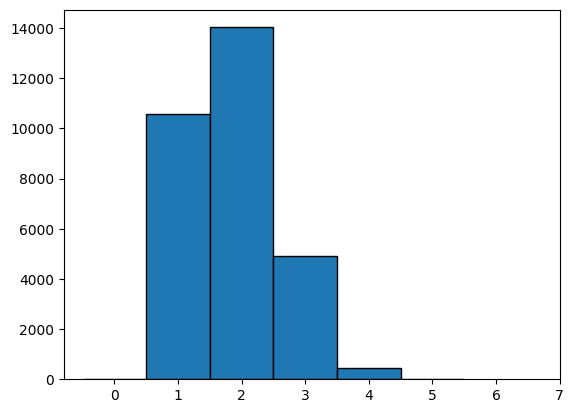

	Education distribution before cleaning:  {1: 0.35283333333333333, 2: 0.4676666666666667, 3: 0.1639, 4: 0.0156}
	Total rows: 30000
	4.1 EDUCATION column cleaned successfully, values are valid now.
	Education distribution after cleaning:  {1: 0.35283333333333333, 2: 0.4676666666666667, 3: 0.1639, 4: 0.0156}
5. MARRIAGE column values are valid.
	Marriage distribution:  {1: 0.4553, 2: 0.5321333333333333, 3: 0.012566666666666667}


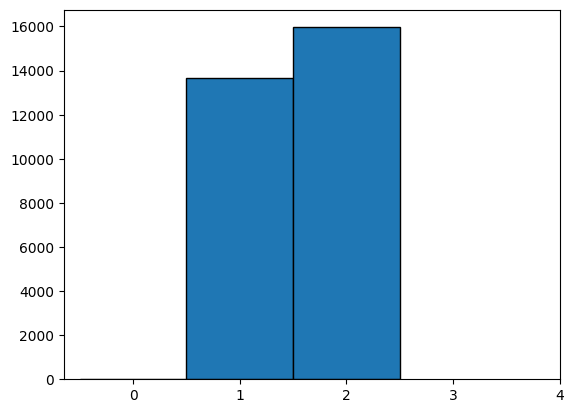

	5.1 MARRIAGE column cleaned successfully, values are valid now.
6. AGE column values are valid.
7. Checking PAY_1 to PAY_6 columns for invalid values.
	Renamed PAY_0 to PAY_1 for consistency.
	PAY_1 column values are valid.
	PAY_2 column values are valid.
	PAY_3 column values are valid.
	PAY_4 column values are valid.
	PAY_5 column values are valid.
	PAY_6 column values are valid.
8. Checking BILL_AMT1 distribution. Understand what amount means for BILL_AMTx.


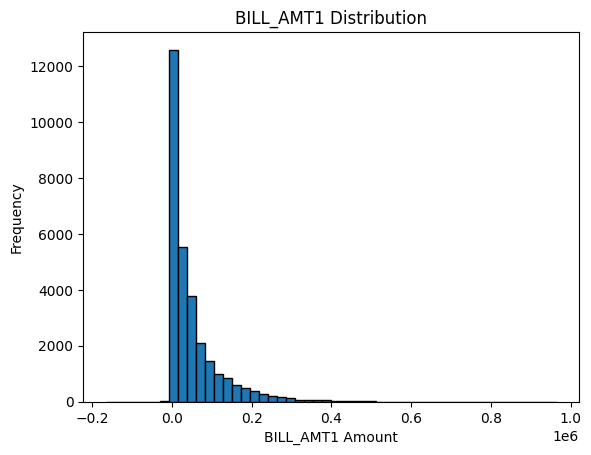

	The maximum percentage of negative of all BILL_AMTx:  0.022933333333333333
9. Checking PAY_AMT1 distribution. Understand what amount means for PAY_AMTx.


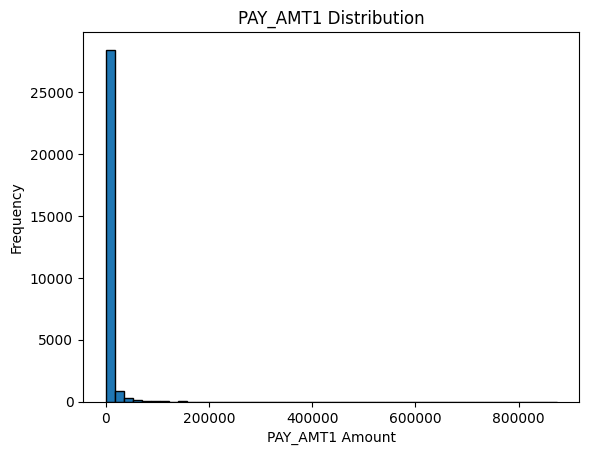

	PAY_AMT1 column has no negative values.
	PAY_AMT2 column has no negative values.
	PAY_AMT3 column has no negative values.
	PAY_AMT4 column has no negative values.
	PAY_AMT5 column has no negative values.
	PAY_AMT6 column has no negative values.
10. default.payment.next.month column values are valid.
	Target value distribution (default.payment.next.month):  {0: 0.7788, 1: 0.2212}
11. LIMIT_BAL column values are valid.


In [87]:
# 1. Check whether there is any missing value in the dataset, here the result is 0, means no missing value at all in the dataset
missing_value = sum(data.isnull().sum())
print("1. Missing values total for all columns: ", missing_value)

# 2. The ID is the ID of each client, it has to be unique for each client, check uniqueness
if not data['ID'].nunique() == data['ID'].count():
    print("2. Warning: ID column has non-unique values.")
else:
    print("2. ID column is unique for each client.")

# 3. Sex is gender 1=male and 2=female, it can't be other values
wrong_sex = data[~data['SEX'].isin([1, 2])]
if wrong_sex.count().sum() == 0:
    print("3. SEX column values are valid.")
else:
    print("3. Warning: SEX column has invalid values.")

# 4. Education: (1=graduate school, 2=university, 3=high school, 4=others, 5=unknown, 6=unknown), first check whether there is any value outside of 1-6, then check the distribution of data, we need to figure out whether merge 5 and 6 to 4
wrong_education = data[(data['EDUCATION'] > 6) | (data['EDUCATION'] < 1)]
if wrong_education.count().sum() == 0:
    print("4. EDUCATION column values are valid.")
else:
    print("4. Warning: EDUCATION column has invalid values.", wrong_education['EDUCATION'].tolist())

# Here we have invalid values in EDUCATION column, let's check the distribution of EDUCATION column with histogram
plt.hist(data['EDUCATION'], bins=np.arange(0, 7)-0.5, edgecolor='black')
plt.xticks(range(0, 8))
plt.show()

print("\tEducation distribution before cleaning: ", (data['EDUCATION'].value_counts().sort_index()/len(data)).to_dict())
print(f"\tTotal rows: {len(data)}")

# We can observe the category 0, 4, 5 and 6 have small percentage of data, they are invalide, unknow or others, we can merge them all into bucket 4, the reason is the percentage is small, also we can avoid deleting data or tiny categories that cause instability.

# Clean EDUCATION: merge 0, 5, 6 into 4 (others/unknown), the final categories: 1=graduate school, 2=university, 3=high school, 4=others/unknown
data['EDUCATION'] = data['EDUCATION'].replace([0, 5, 6], 4)

# Make sure now the EDUCATION column only has values from 1 to 4
wrong_education = data[(data['EDUCATION'] > 4) | (data['EDUCATION'] < 1)]
if wrong_education.count().sum() == 0:
    print("\t4.1 EDUCATION column cleaned successfully, values are valid now.")
else:
    print("\t4.1 Warning: EDUCATION column still has invalid values.", wrong_education['EDUCATION'].unique().tolist())

print("\tEducation distribution after cleaning: ", (data['EDUCATION'].value_counts().sort_index()/len(data)).to_dict())
# 5. Check mariage status, 1=married, 2=single, 3=others, check whether there is any value outside of 1-3
wrong_marriage = data[~data['MARRIAGE'].isin([1, 2, 3])]
if wrong_marriage.count().sum() == 0:
    print("5. MARRIAGE column values are valid.")
else:
    print("5. Warning: MARRIAGE column has invalid values.", wrong_marriage['MARRIAGE'].unique().tolist())

# Check the distribution of Marriage column, if the percentage of 0 is small, we can consider merge it to others(3)
print("\tMarriage distribution: ", (data['MARRIAGE'].value_counts().sort_index()/len(data)).to_dict())

plt.hist(data['MARRIAGE'], bins=np.arange(0, 4)-0.5, edgecolor='black')
plt.xticks(range(0, 5))
plt.show()

# Category 0 has 0: 0.0018 and 3: 0.0108, they both are quite small percentage, let's merge 0 to 3
data['MARRIAGE'] = data['MARRIAGE'].replace(0, 3)

# Check again whether MARRIAGE column only has values from 1 to 3
wrong_marriage = data[~data['MARRIAGE'].isin([1, 2, 3])]
if wrong_marriage.count().sum() == 0:
    print("\t5.1 MARRIAGE column cleaned successfully, values are valid now.")
else:
    print("\t5.1 Warning: MARRIAGE column still has invalid values.", wrong_marriage['MARRIAGE'].unique().tolist()) 

# 6. Age in years, check whether there is any negative value or extremely high value(e.g., >100)
wrong_age = data[(data['AGE'] <= 0) | (data['AGE'] > 100)]
if wrong_age.count().sum() == 0:
    print("6. AGE column values are valid.")
else:
    print("6. Warning: AGE column has invalid values.", wrong_age['AGE'].unique().tolist())

# 7. The columns PAY_0 to PAY_6 are the repayment status from September 2005 to April 2005, check whether there is any value outside of -1 and 1 - 9, we actually found -2 and 0, they are a big percentage in the dataset, let's keep them and explain their meaning later. The valid values [-2, 9]

# first rename PAY_0 to PAY_1, to align with BILL_AMT1 and PAY_AMT1, they are all data for september 2005
print("7. Checking PAY_1 to PAY_6 columns for invalid values.")
data = data.rename(columns={'PAY_0': 'PAY_1'})
print("\tRenamed PAY_0 to PAY_1 for consistency.")
for col in ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']:
    wrong_pay = data[~data[col].isin([-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9])]
    if wrong_pay.count().sum() == 0:
        print(f"\t{col} column values are valid.")
    else:
        print(f"\tWarning: {col} column has invalid values.", wrong_pay[col].unique().tolist(), "total row wrong in percentage: ", wrong_pay[col].count().sum()/len(data))

# 8. The columns BILL_AMT1 to BILL_AMT6 are the amount of bill statement from September 2005 to April 2005, it can be negative or zero, but it should be rare, that means the bank owe money to the client, check the distribution of BILL_AMT1 to make sure what does it mean by amount.
print("8. Checking BILL_AMT1 distribution. Understand what amount means for BILL_AMTx.")
plt.hist(data['BILL_AMT1'], bins=50, edgecolor='black')
plt.title('BILL_AMT1 Distribution')
plt.xlabel('BILL_AMT1 Amount')
plt.ylabel('Frequency')
plt.show()

max_negative_bill = (data['BILL_AMT1'] < 0).sum()
for i in range(1, 7):
    negative_bill = (data[f'BILL_AMT{i}'] < 0).sum()
    if negative_bill > max_negative_bill:
        max_negative_bill = negative_bill
print("\tThe maximum percentage of negative of all BILL_AMTx: ", max_negative_bill/len(data))

# Here the maximum of all BILL_AMTx negative percentage is 0.0225, it is quite small, we can keep them as it is.

# 9. The columns PAY_AMT1 to PAY_AMT6 are the amount of previous payment from September 2005 to April 2005, check the distribution of PAY_AMT1 to make sure what does it mean by amount.
print("9. Checking PAY_AMT1 distribution. Understand what amount means for PAY_AMTx.")
plt.hist(data['PAY_AMT1'], bins=50, edgecolor='black')
plt.title('PAY_AMT1 Distribution')
plt.xlabel('PAY_AMT1 Amount')
plt.ylabel('Frequency')
plt.show()

# Check whether there is negative values, it shouldn't be negative
for i in range(1, 7):
    negative_pay = (data[f'PAY_AMT{i}'] < 0).sum()
    if negative_pay > 0:
        print(f"\tWarning: PAY_AMT{i} column has negative values.", negative_pay)
    else:
        print(f"\tPAY_AMT{i} column has no negative values.")

# 10. The target value default.payment.next.month, when it is 1, means the client defaulted on their payment the next month (October 2005), when it is 0, means they did not default. since its type is int64, and only has 0 and 1 values, let's check the data are valid.
wrong_target = data[~data['default.payment.next.month'].isin([0, 1])]
if wrong_target.count().sum() == 0:
    print("10. default.payment.next.month column values are valid.")
else:
    print("10. Warning: default.payment.next.month column has invalid values.", wrong_target['default.payment.next.month'].unique().tolist())

# Check the distribution of target value in order to get the balance of the dataset
target_distribution = data['default.payment.next.month'].value_counts(normalize=True)
print("\tTarget value distribution (default.payment.next.month): ", target_distribution.to_dict())

# The data is imbalanced, the percentage of not defaulted clients is around 22.12%, we may need to consider this when we build the model later.

# 11. Check LIMIT_BAL: Amount of given credit in NT dollars (includes individual and family/supplementary credit), it should be positive values only
wrong_limit_bal = data[data['LIMIT_BAL'] <= 0]
if wrong_limit_bal.count().sum() == 0:
    print("11. LIMIT_BAL column values are valid.")
else:
    print("11. Warning: LIMIT_BAL column has invalid values.", wrong_limit_bal['LIMIT_BAL'].unique().tolist())

# We have check that the LIMIT_BAL column can be higher than the maximum BILL_AMTx values, that means the credit limit can be higher than the current bill amount, which is reasonable. And should be kept as it is. We may consider use it as a feature later.


# 4. Split training, validation and test dataset.

In [95]:
# First we seperate features (X) and target (Y)
X = data.drop(['ID', 'default.payment.next.month'], axis=1)
y = data['default.payment.next.month']

# First split: separate test set (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% for final testing
    random_state=42,    # For reproducibility
    stratify=y          # Maintain class balance
)

# Second split: split remaining 80% into train (60% of total) and validation (20% of total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,     # 25% of 80% = 20% of total
    random_state=42,
    stratify=y_temp
)

print("Training, validation and test data numbers are: ", len(X_train), len(X_val), len(X_test), "respectively.")

Training, validation and test data numbers are:  18000 6000 6000 respectively.
